### 1) Import Pandas and Numpy

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### 2) Import the dataset and  Assign it to a variable called Chipo

#### Import the dataset from
https://github.com/justmarkham/pandas-videos/blob/master/data/chipotle.tsv

#### REMEMBER: It is a .tsv file , you will have to do some research on how to read .tsv files first!

In [2]:
chipo = pd.read_csv('chipotle.tsv', sep='\t')
chipo.head()

,order_id,quantity,item_name,choice_description,item_price
0,1,1,Chips and Fresh Tomato Salsa,NaN,$2.39
1,1,1,Izze,[Clementine],$3.39
2,1,1,Nantucket Nectar,[Apple],$3.39
3,1,1,Chips and Tomatillo-Green Chili Salsa,NaN,$2.39
4,2,2,Chicken Bowl,"[Tomatillo-Red Chili Salsa (Hot), [Black Beans...",$16.98


### 3) See the first 10 entries

In [3]:
chipo.head(10)

,order_id,quantity,item_name,choice_description,item_price
0,1,1,Chips and Fresh Tomato Salsa,NaN,$2.39
1,1,1,Izze,[Clementine],$3.39
2,1,1,Nantucket Nectar,[Apple],$3.39
3,1,1,Chips and Tomatillo-Green Chili Salsa,NaN,$2.39
4,2,2,Chicken Bowl,"[Tomatillo-Red Chili Salsa (Hot), [Black Beans...",$16.98
5,3,1,Chicken Bowl,"[Fresh Tomato Salsa (Mild), [Rice, Cheese, Sou...",$10.98
6,3,1,Side of Chips,NaN,$1.69
7,4,1,Steak Burrito,"[Tomatillo Red Chili Salsa, [Fajita Vegetables...",$11.75
8,4,1,Steak Soft Tacos,"[Tomatillo Green Chili Salsa, [Pinto Beans, Ch...",$9.25
9,5,1,Steak Burrito,"[Fresh Tomato Salsa, [Rice, Black Beans, Pinto...",$9.25


### 4) What is the number of observations in the dataset?

In [4]:
print('Number of observations:', len(chipo))

Number of observations: 4622


### 5) What is the number of columns in the dataset?

In [5]:
print('Number of columns:', len(chipo.columns))

Number of columns: 5


### 6) Print the name of all the columns.

In [6]:
print('Columns:', chipo.columns.tolist())

Columns: ['order_id', 'quantity', 'item_name', 'choice_description', 'item_price']


### 7) Which was the most-ordered item?

In [7]:
most_ordered = chipo.groupby('item_name')['quantity'].sum().idxmax()
print('Most ordered item:', most_ordered)

Most ordered item: Chicken Bowl


### 8) For the most-ordered item, how many items were ordered?

In [8]:
most_ordered_count = chipo.groupby('item_name')['quantity'].sum().max()
print('Number of times ordered:', most_ordered_count)

Number of times ordered: 761


### 9) What was the most ordered item in the choice_description column?

In [9]:
print('Most ordered choice:', chipo['choice_description'].value_counts().idxmax())

Most ordered choice: [Diet Coke]


### 10) How many items were ordered in total?

In [10]:
print('Total items ordered:', chipo['quantity'].sum())

Total items ordered: 4972


### 11) Turn the item price into a float

In [11]:
chipo['item_price'] = pd.to_numeric(chipo['item_price'].str.extract(r'(\d+\.\d+)')[0])
print('Data type now:', chipo['item_price'].dtype)
chipo['item_price'].head()

Data type now: float64


0     2.39
1     3.39
2     3.39
3     2.39
4    16.98
Name: item_price, dtype: float64

### 12) How much was the revenue for the period in the dataset?
#### Revenue will be the sum of quantity * item_price!

In [12]:
chipo['revenue'] = chipo['quantity'] * chipo['item_price']
total_revenue = chipo['revenue'].sum()
print('Total Revenue: $', round(total_revenue, 2))

Total Revenue: $ 39237.02


### 13) How many orders were made in the period?

In [13]:
print('Total orders:', chipo['order_id'].nunique())

Total orders: 1834


### 14) What is the average revenue amount per order?

In [14]:
avg_revenue = chipo.groupby('order_id')['revenue'].sum().mean()
print('Average revenue per order: $', round(avg_revenue, 2))

Average revenue per order: $ 21.39


### 15) How many different items are sold?

In [15]:
print('Different items sold:', chipo['item_name'].nunique())

Different items sold: 50


### 16) Show a histogram with number of orders with bill on the x-axis.

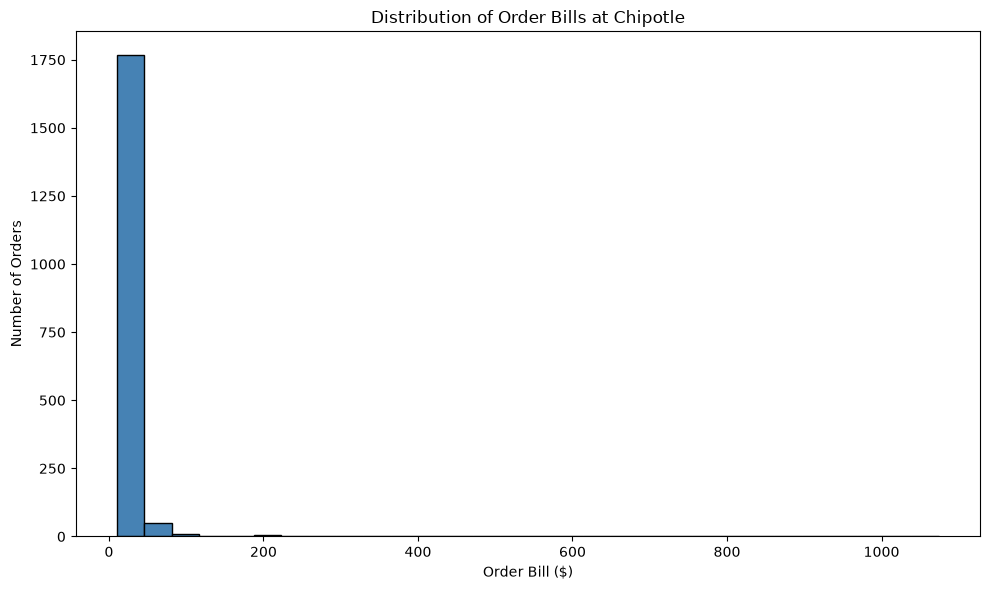

In [16]:
order_bills = chipo.groupby('order_id')['revenue'].sum()

plt.figure(figsize=(10, 6))
plt.hist(order_bills, bins=30, color='steelblue', edgecolor='black')
plt.xlabel('Order Bill ($)')
plt.ylabel('Number of Orders')
plt.title('Distribution of Order Bills at Chipotle')
plt.tight_layout()
plt.show()